Generation 1 : Best Affinity = 0.1989
Generation 2 : Best Affinity = 0.27
Generation 3 : Best Affinity = 0.3123
Generation 4 : Best Affinity = 0.3337
Generation 5 : Best Affinity = 0.3337
Generation 6 : Best Affinity = 0.3337
Generation 7 : Best Affinity = 0.3342
Generation 8 : Best Affinity = 0.3342
Generation 9 : Best Affinity = 0.3342
Generation 10 : Best Affinity = 0.3342
Generation 11 : Best Affinity = 0.3342
Generation 12 : Best Affinity = 0.3342
Generation 13 : Best Affinity = 0.3342
Generation 14 : Best Affinity = 0.3342
Generation 15 : Best Affinity = 0.3342
Generation 16 : Best Affinity = 0.3342
Generation 17 : Best Affinity = 0.3342
Generation 18 : Best Affinity = 0.3342
Generation 19 : Best Affinity = 0.3342
Generation 20 : Best Affinity = 0.3342
Generation 21 : Best Affinity = 0.3342
Generation 22 : Best Affinity = 0.3342
Generation 23 : Best Affinity = 0.3342
Generation 24 : Best Affinity = 0.3342
Generation 25 : Best Affinity = 0.3342
Generation 26 : Best Affinity = 0.33

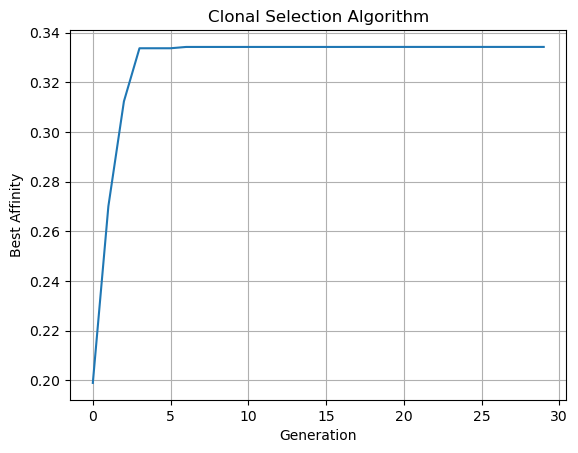

In [3]:
!pip install numpy

# ---------------------------------------------------------
# CLONAL SELECTION ALGORITHM
# ---------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Fitness Function (Rastrigin Function)it is a mathematical test function used to check how well an optimization algorithm works.
# ---------------------------------------------------------

def rastrigin(x):
    A = 10
    return A * len(x) + sum((xi**2 - A * np.cos(2 * np.pi * xi)) for xi in x)

# ---------------------------------------------------------
# Generate Initial Population
# ---------------------------------------------------------

def create_population(size, dimension, bounds):
    population = []
    for i in range(size):
        individual = np.random.uniform(bounds[0], bounds[1], dimension)
        population.append(individual)
    return population

# ---------------------------------------------------------
# Affinity Calculation
# ---------------------------------------------------------

def calculate_affinity(population):
    affinity = []
    for individual in population:
        fit = rastrigin(individual)
        affinity.append(1 / (1 + fit))
    return affinity

# ---------------------------------------------------------
# Clone and Mutate
# ---------------------------------------------------------

def clone_and_mutate(selected, clone_factor, mutation_rate, bounds):
    clones = []
    for individual in selected:
        for i in range(clone_factor):
            clone = individual.copy()
            mutation = np.random.uniform(-mutation_rate, mutation_rate, len(clone))
            clone = clone + mutation
            clone = np.clip(clone, bounds[0], bounds[1])
            clones.append(clone)
    return clones

# ---------------------------------------------------------
# Parameters
# ---------------------------------------------------------

POPULATION_SIZE = 20
GENERATIONS = 30
CLONE_FACTOR = 5
MUTATION_RATE = 0.1
DIMENSION = 2
BOUNDS = (-5.12, 5.12)

# ---------------------------------------------------------
# Main Algorithm
# ---------------------------------------------------------

population = create_population(POPULATION_SIZE, DIMENSION, BOUNDS)
best_affinity_history = []

for generation in range(GENERATIONS):
    affinity = calculate_affinity(population)

    indices = np.argsort(affinity)[-POPULATION_SIZE // 2:]
    selected = [population[i] for i in indices]

    clones = clone_and_mutate(selected, CLONE_FACTOR, MUTATION_RATE, BOUNDS)

    population = population + clones

    affinity = calculate_affinity(population)

    indices = np.argsort(affinity)[-POPULATION_SIZE:]
    population = [population[i] for i in indices]

    best_affinity = max(affinity)
    best_affinity_history.append(best_affinity)

    print("Generation", generation + 1, ": Best Affinity =", round(best_affinity, 4))

# ---------------------------------------------------------
# Final Best Solution
# ---------------------------------------------------------

final_affinity = calculate_affinity(population)
best_index = np.argmax(final_affinity)
best_solution = population[best_index]

print("\nBest Solution :", best_solution)
print("Best Affinity :", round(final_affinity[best_index], 4))

# ---------------------------------------------------------
# Visualization
# ---------------------------------------------------------

plt.plot(best_affinity_history)
plt.title("Clonal Selection Algorithm")
plt.xlabel("Generation")
plt.ylabel("Best Affinity")
plt.grid()
plt.show()